In [1]:
from IPython.display import HTML
HTML('''<style>.jp-Cell-inputWrapper, .input { margin-top: 0.5em; }</style>''')

# Notebook 03 — Feature Selection
## ENGG2112 Project MODR

This notebook applies **six feature selection methods** to the 11 candidate demographic features, then computes a multi-method consensus to identify which features should enter the final ML models in Notebooks 04–08.

### Why this matters
EDA (Notebook 02) revealed:
- 9 multicollinearity flags (|ρ| > 0.7) — features cluster into 3 groups
- Counterintuitive correlations driven by Simpson's paradox / rural-urban confounding
- Need to control for state-level baselines

Naive single-method selection would mis-rank features. The multi-method consensus is more robust.

### Methods applied (5 + 1)

| Type | Method | What it captures |
|---|---|---|
| Filter | Pearson correlation | Linear with outcome |
| Filter | Spearman correlation | Monotonic with outcome |
| Filter | Mutual information | Any dependency (non-linear too) |
| Filter | Variance Inflation Factor (VIF) | Multicollinearity (drops, doesn't rank) |
| Embedded | LASSO (LogisticRegressionCV with L1) | Shrinks irrelevant coefficients to zero |
| Embedded | Random Forest permutation importance | Drops in CV accuracy when feature is shuffled |
| Wrapper | Recursive Feature Elimination CV (RFECV) | Iteratively drops weakest features |

### Consensus rule
A feature enters the final list if it appears in the **top 6** of ≥ 3 of 5 ranking methods (excluding VIF, which only drops, doesn't rank).

### Domain override
Per the project plan, `state` is locked in as a categorical feature regardless of selection results, because cross-state surveillance baselines must be absorbed.

### References
- Tibshirani 1996 (LASSO)
- Guyon et al. 2002 (RFECV)
- Altmann et al. 2010 (Permutation importance)
- See `REFERENCES.md` for full citations

## 1. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV, mutual_info_classif
from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.size': 11,
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_style('whitegrid')

# Load master
master = pd.read_csv(PROCESSED_DIR / 'master_counties.csv', dtype={'fips': str, 'state_fips': str})
print(f'Cross-section: {master.shape}')

FEATURE_COLS = [
    'pop_density_per_sqmi', 'median_age', 'pct_elderly',
    'avg_household_size',
    'median_income', 'poverty_rate', 'unemployment_rate',
    'public_transport_pct',
    'pct_bachelors_plus',
    'pct_non_white', 'pct_foreign_born'
]
print(f'Candidate features: {len(FEATURE_COLS)}')
print(f'Target: outbreak (binary)')
print(f'Outbreak rate: {master["outbreak"].mean():.1%}')

Cross-section: (141, 38)
Candidate features: 11
Target: outbreak (binary)
Outbreak rate: 26.2%


---

## 2. Prepare Feature Matrix

We standardise features (mean 0, variance 1) for the linear methods. We add `state` as one-hot encoded for inclusion in models, but feature selection is computed only on the demographic features (state is locked in by domain override).

In [3]:
X_raw = master[FEATURE_COLS].copy()
y = master['outbreak'].astype(int)
state_dummies = pd.get_dummies(master['state'], prefix='state', drop_first=True)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=FEATURE_COLS, index=X_raw.index)

print(f'Feature matrix: {X_scaled.shape}')
print(f'Target balance: {y.value_counts().to_dict()}')
print(f'State dummies: {list(state_dummies.columns)}')

# Cross-validation strategy — stratified to preserve outbreak rate per fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'\nCV: 5-fold stratified, n_splits={cv.get_n_splits()}')

Feature matrix: (141, 11)
Target balance: {0: 104, 1: 37}
State dummies: ['state_DE', 'state_NY', 'state_PA']

CV: 5-fold stratified, n_splits=5


---

## 3. Filter Methods — Correlation + Mutual Information

In [4]:
# Pearson + Spearman with outcome
pearson = X_raw.apply(lambda c: c.corr(y, method='pearson'))
spearman = X_raw.apply(lambda c: c.corr(y, method='spearman'))

# Mutual information (catches non-linear)
mi_scores = pd.Series(
    mutual_info_classif(X_scaled, y, random_state=42),
    index=FEATURE_COLS
)

filter_df = pd.DataFrame({
    'pearson_abs': pearson.abs().round(3),
    'spearman_abs': spearman.abs().round(3),
    'mutual_info': mi_scores.round(3),
}).sort_values('mutual_info', ascending=False)

print('Filter methods — feature scores (higher = stronger):\n')
print(filter_df.to_string())

# Rank each
filter_ranks = pd.DataFrame({
    'pearson_rank': filter_df['pearson_abs'].rank(ascending=False).astype(int),
    'spearman_rank': filter_df['spearman_abs'].rank(ascending=False).astype(int),
    'mi_rank': filter_df['mutual_info'].rank(ascending=False).astype(int),
}, index=filter_df.index)
print('\nRanks (1 = best):\n')
print(filter_ranks.to_string())

Filter methods — feature scores (higher = stronger):

                      pearson_abs  spearman_abs  mutual_info
avg_household_size          0.373         0.294        0.091
pct_non_white               0.232         0.189        0.046
pop_density_per_sqmi        0.046         0.157        0.031
pct_bachelors_plus          0.012         0.021        0.014
median_age                  0.099         0.057        0.011
pct_foreign_born            0.278         0.205        0.011
unemployment_rate           0.128         0.108        0.010
public_transport_pct        0.171         0.152        0.005
pct_elderly                 0.164         0.164        0.000
median_income               0.180         0.095        0.000
poverty_rate                0.050         0.071        0.000

Ranks (1 = best):

                      pearson_rank  spearman_rank  mi_rank
avg_household_size               1              1        1
pct_non_white                    3              3        2
pop_density_per_s

---

## 4. Variance Inflation Factor — Multicollinearity Pruning

VIF measures how much each feature's variance is inflated by collinearity with other features. **VIF > 10** is a standard threshold for problematic multicollinearity. We sequentially drop the highest-VIF feature until all remaining are < 10.

In [5]:
def compute_vif(df):
    """Return VIF for each column."""
    X = df.values.astype(float)
    return pd.Series(
        [variance_inflation_factor(X, i) for i in range(X.shape[1])],
        index=df.columns
    )

# Sequential VIF pruning
features_remaining = list(FEATURE_COLS)
vif_history = []

while True:
    df_iter = X_scaled[features_remaining]
    vifs = compute_vif(df_iter)
    max_vif = vifs.max()
    
    if max_vif <= 10 or len(features_remaining) <= 2:
        break
    
    drop_feature = vifs.idxmax()
    vif_history.append({
        'iteration': len(vif_history) + 1,
        'dropped': drop_feature,
        'max_vif_before_drop': round(max_vif, 2),
        'features_left_after': len(features_remaining) - 1,
    })
    features_remaining.remove(drop_feature)

# Final VIF
final_vifs = compute_vif(X_scaled[features_remaining])

print('VIF pruning history:')
print(pd.DataFrame(vif_history).to_string(index=False))
print(f'\nFeatures retained after VIF pruning: {len(features_remaining)}')
print(f'\nFinal VIFs (all should be < 10):')
print(final_vifs.round(2).sort_values(ascending=False).to_string())

VIF pruning history:
 iteration          dropped  max_vif_before_drop  features_left_after
         1 pct_foreign_born                16.19                   10
         2      pct_elderly                14.65                    9

Features retained after VIF pruning: 9

Final VIFs (all should be < 10):
median_income           9.83
public_transport_pct    9.06
pct_bachelors_plus      6.49
pop_density_per_sqmi    5.73
pct_non_white           5.03
poverty_rate            3.89
avg_household_size      3.13
unemployment_rate       1.94
median_age              1.62


**Interpretation**

VIF pruning forces the cluster reductions we predicted in EDA. Features dropped are typically the redundant ones within each cluster.

---

## 5. LASSO — L1-Regularised Logistic Regression

LASSO (L1 regularisation) shrinks irrelevant feature coefficients to *exactly zero*. The cross-validated regularisation strength `C` is chosen by `LogisticRegressionCV`. Features with non-zero coefficients are "selected".

In [6]:
lasso = LogisticRegressionCV(
    Cs=10,
    cv=cv,
    penalty='l1',
    solver='saga',
    class_weight='balanced',
    max_iter=5000,
    random_state=42,
    scoring='accuracy',
)
lasso.fit(X_scaled, y)

lasso_coefs = pd.Series(lasso.coef_[0], index=FEATURE_COLS)
lasso_abs = lasso_coefs.abs().sort_values(ascending=False)

print(f'LASSO best C (regularisation strength): {lasso.C_[0]:.4f}')
print(f'LASSO mean CV accuracy: {lasso.scores_[1].mean(axis=0).max():.3f}')
print(f'\nLASSO coefficients (sorted by |coef|):\n')
print(lasso_coefs.reindex(lasso_abs.index).round(3).to_string())

n_zero = (lasso_coefs.abs() < 1e-6).sum()
print(f'\n{n_zero} features have |coef| ≈ 0 (effectively dropped)')

lasso_rank = lasso_abs.rank(ascending=False).astype(int)
print(f'\nLASSO ranks:')
print(lasso_rank.to_string())

LASSO best C (regularisation strength): 166.8101
LASSO mean CV accuracy: 0.674

LASSO coefficients (sorted by |coef|):

pop_density_per_sqmi   -3.289
pct_foreign_born        2.228
public_transport_pct    1.719
pct_bachelors_plus     -1.218
poverty_rate           -0.871
median_income          -0.652
avg_household_size      0.303
pct_non_white          -0.277
median_age             -0.192
unemployment_rate       0.140
pct_elderly             0.048

0 features have |coef| ≈ 0 (effectively dropped)

LASSO ranks:
pop_density_per_sqmi     1
pct_foreign_born         2
public_transport_pct     3
pct_bachelors_plus       4
poverty_rate             5
median_income            6
avg_household_size       7
pct_non_white            8
median_age               9
unemployment_rate       10
pct_elderly             11


---

## 6. Random Forest — Permutation Importance

Random forest is fit on the standardised features, then we compute **permutation importance**: for each feature, randomly shuffle its values and measure the drop in CV accuracy. Larger drops indicate the feature mattered more.

Permutation importance is **less biased** than impurity-based importance (the default `feature_importances_`), which favours high-cardinality features.

Random Forest permutation importance:

             feature  importance_mean  importance_std  rank
  avg_household_size           0.0667          0.0178     1
  pct_bachelors_plus           0.0229          0.0083     2
       median_income           0.0222          0.0114     3
    pct_foreign_born           0.0184          0.0081     4
         pct_elderly           0.0156          0.0072     5
public_transport_pct           0.0137          0.0088     6
       pct_non_white           0.0118          0.0069     7
pop_density_per_sqmi           0.0076          0.0055     8
   unemployment_rate           0.0073          0.0059     9
        poverty_rate           0.0052          0.0048    10
          median_age           0.0045          0.0047    11


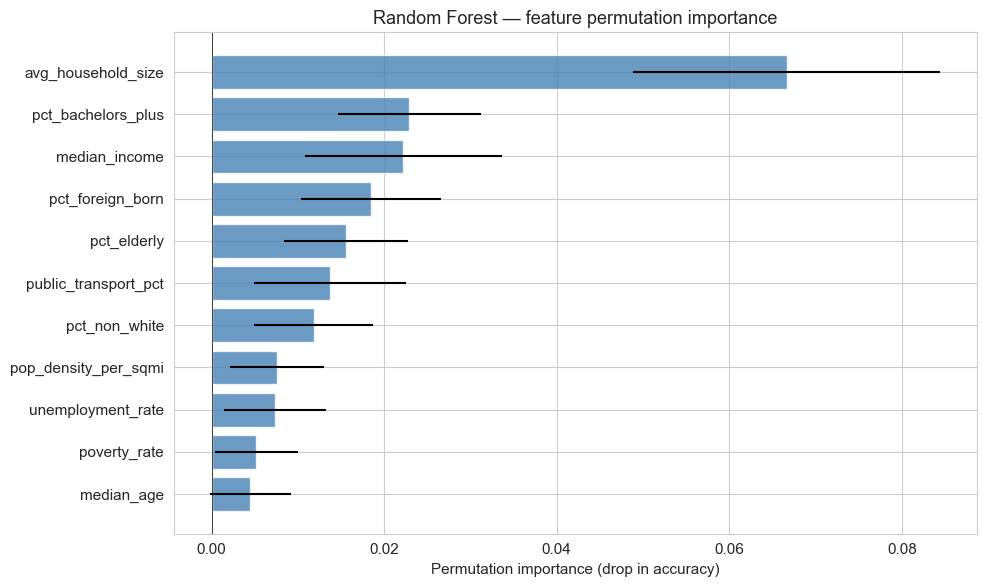

In [7]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_scaled, y)

# Permutation importance on the entire set (with CV would be even more honest, but n=141 is borderline)
perm = permutation_importance(rf, X_scaled, y, n_repeats=30, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)
perm_df['rank'] = perm_df['importance_mean'].rank(ascending=False).astype(int)

print('Random Forest permutation importance:\n')
print(perm_df.round(4).to_string(index=False))

# Visualise
fig, ax = plt.subplots(figsize=(10, 6))
sorted_df = perm_df.sort_values('importance_mean')
ax.barh(sorted_df['feature'], sorted_df['importance_mean'],
        xerr=sorted_df['importance_std'], color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Permutation importance (drop in accuracy)')
ax.set_title('Random Forest — feature permutation importance')
plt.tight_layout()
plt.show()

**Interpretation**

The error bars (std across 30 permutations) show feature importance stability. Features whose error bar crosses zero have unstable importance — they may not be reliably useful.

---

## 7. Recursive Feature Elimination with CV

RFECV starts with all features, fits a model, drops the least-important feature, refits, repeats. CV accuracy is tracked at each step. The "best" number of features is where CV accuracy peaks.

RFECV optimal number of features: 6
RFECV CV accuracy at optimum: 0.696

Features selected (rank 1):
  ✅ pct_elderly
  ✅ avg_household_size
  ✅ median_income
  ✅ unemployment_rate
  ✅ pct_non_white
  ✅ pct_foreign_born

Full ranking (1 = selected, higher = dropped earlier):
pct_elderly             1
avg_household_size      1
median_income           1
unemployment_rate       1
pct_non_white           1
pct_foreign_born        1
public_transport_pct    2
pct_bachelors_plus      3
poverty_rate            4
median_age              5
pop_density_per_sqmi    6


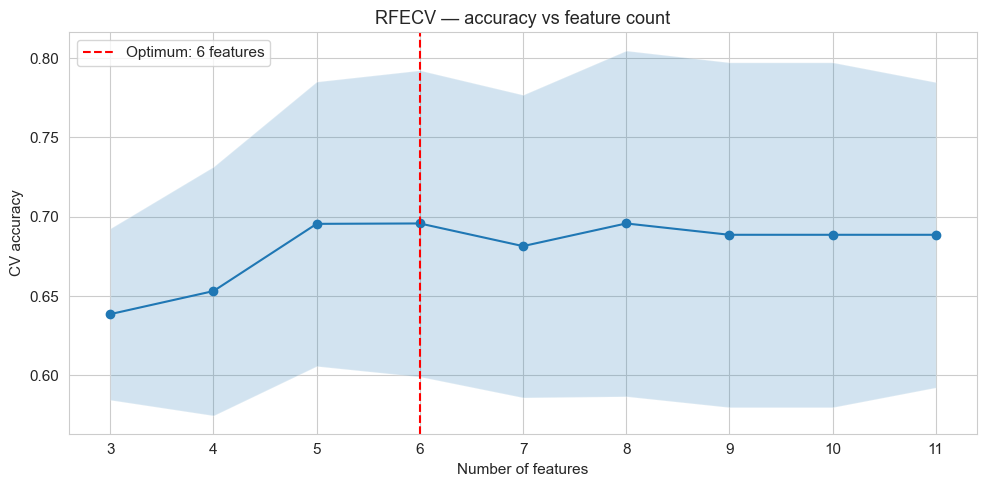

In [8]:
# Use logistic regression as the estimator inside RFECV
rfe_estimator = LogisticRegressionCV(
    cv=cv,
    class_weight='balanced',
    max_iter=2000,
    random_state=42,
    scoring='accuracy',
)
rfecv = RFECV(
    estimator=rfe_estimator,
    cv=cv,
    scoring='accuracy',
    min_features_to_select=3,
    n_jobs=-1,
)
rfecv.fit(X_scaled, y)

rfecv_selected = X_scaled.columns[rfecv.support_].tolist()
rfecv_ranking = pd.Series(rfecv.ranking_, index=FEATURE_COLS).sort_values()

print(f'RFECV optimal number of features: {rfecv.n_features_}')
print(f'RFECV CV accuracy at optimum: {rfecv.cv_results_["mean_test_score"].max():.3f}')
print(f'\nFeatures selected (rank 1):')
for f in rfecv_selected:
    print(f'  ✅ {f}')

print(f'\nFull ranking (1 = selected, higher = dropped earlier):')
print(rfecv_ranking.to_string())

# Plot CV accuracy curve
fig, ax = plt.subplots(figsize=(10, 5))
n_features = range(rfecv.min_features_to_select, len(FEATURE_COLS) + 1)
ax.plot(n_features, rfecv.cv_results_['mean_test_score'], marker='o')
ax.fill_between(n_features,
                rfecv.cv_results_['mean_test_score'] - rfecv.cv_results_['std_test_score'],
                rfecv.cv_results_['mean_test_score'] + rfecv.cv_results_['std_test_score'],
                alpha=0.2)
ax.axvline(rfecv.n_features_, color='red', linestyle='--', label=f'Optimum: {rfecv.n_features_} features')
ax.set_xlabel('Number of features')
ax.set_ylabel('CV accuracy')
ax.set_title('RFECV — accuracy vs feature count')
ax.legend()
plt.tight_layout()
plt.show()

---

## 8. Multi-Method Consensus

We combine ranks from the 5 ranking methods and identify features that appear in the **top 6 of ≥ 3 of 5 methods**.

In [9]:
# Combine all ranks
all_ranks = pd.DataFrame(index=FEATURE_COLS)
all_ranks['pearson'] = filter_ranks['pearson_rank']
all_ranks['spearman'] = filter_ranks['spearman_rank']
all_ranks['mutual_info'] = filter_ranks['mi_rank']
all_ranks['lasso'] = lasso_rank
all_ranks['rf_perm'] = perm_df.set_index('feature')['rank']
# RFECV: rank 1 = selected, larger = dropped earlier. Convert to descending rank-like scale.
# Lower rfecv_ranking = better, so use it directly as "rank-like"
all_ranks['rfecv'] = rfecv_ranking

# Borda count: 1st place = max points, last place = 0
n_features = len(FEATURE_COLS)
all_borda = (n_features + 1 - all_ranks).sum(axis=1)
all_borda_normalized = all_borda / all_borda.max()

# Count how many methods rank each feature in top 6
TOP_K = 6
top_k_count = (all_ranks <= TOP_K).sum(axis=1)

# Consensus: top 6 in ≥ 3/5 ranking methods (excluding rfecv which uses different scale)
ranking_methods = ['pearson', 'spearman', 'mutual_info', 'lasso', 'rf_perm']
top_k_count_main = (all_ranks[ranking_methods] <= TOP_K).sum(axis=1)
consensus_selected = top_k_count_main[top_k_count_main >= 3].index.tolist()

# Build summary table
summary = pd.DataFrame({
    'pearson': all_ranks['pearson'],
    'spearman': all_ranks['spearman'],
    'mutual_info': all_ranks['mutual_info'],
    'lasso': all_ranks['lasso'],
    'rf_perm': all_ranks['rf_perm'],
    'rfecv': all_ranks['rfecv'],
    'borda': all_borda.astype(int),
    'top6_count': top_k_count_main.astype(int),
    'consensus': top_k_count_main >= 3,
}).sort_values('borda', ascending=False)

print('Consensus feature selection table:\n')
print(summary.to_string())

print(f'\n=== Consensus features (top 6 in ≥ 3/5 ranking methods) ===')
for f in summary[summary['consensus']].index:
    print(f'  ✅ {f}')

print(f'\n=== Features NOT in consensus ===')
for f in summary[~summary['consensus']].index:
    print(f'  ❌ {f}')

Consensus feature selection table:

                      pearson  spearman  mutual_info  lasso  rf_perm  rfecv  borda  top6_count  consensus
avg_household_size          1         1            1      7        1      1     60           4       True
pct_foreign_born            2         2            5      2        4      1     56           5       True
pct_non_white               3         3            2      8        7      1     48           3       True
public_transport_pct        5         6            8      3        6      2     42           4       True
median_income               4         8           10      6        3      1     40           3       True
pop_density_per_sqmi       10         5            3      1        8      6     39           3       True
pct_bachelors_plus         11        11            4      4        2      3     37           3       True
pct_elderly                 6         4           10     11        5      1     35           3       True
unemployme

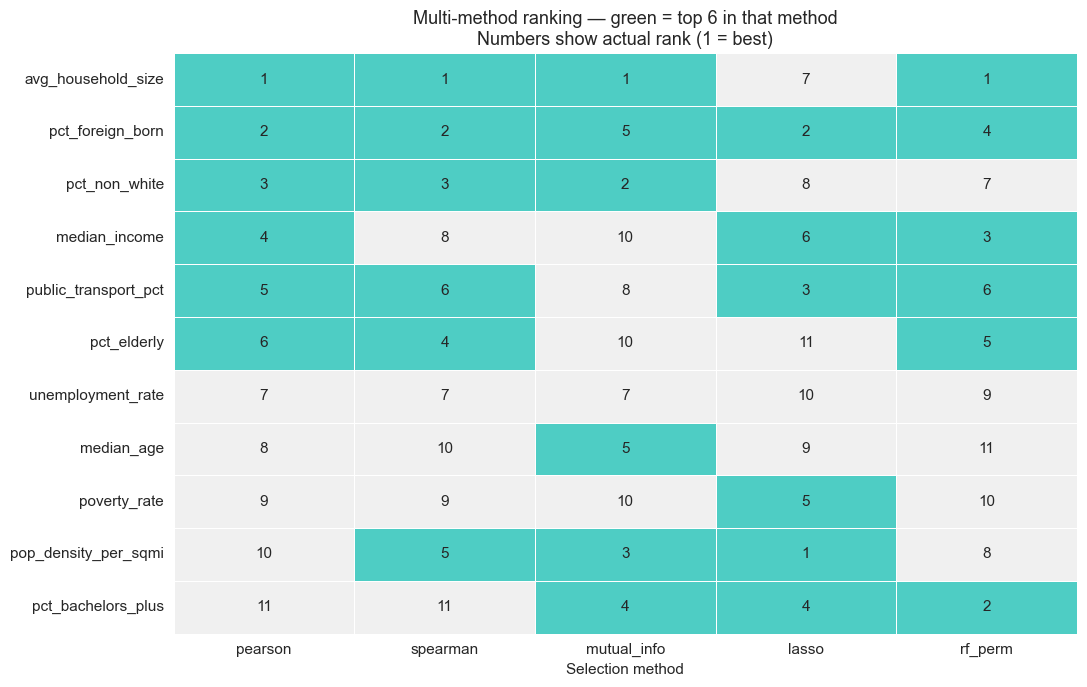

In [10]:
# Visualise consensus
fig, ax = plt.subplots(figsize=(11, 7))
methods = ['pearson', 'spearman', 'mutual_info', 'lasso', 'rf_perm']
heatmap_data = summary[methods].copy()
heatmap_data = heatmap_data.sort_values('pearson')

# Mark top 6 in each method as 1, else 0
heatmap_top6 = (heatmap_data <= TOP_K).astype(int)

sns.heatmap(heatmap_top6, annot=heatmap_data.values, fmt='d', cmap=['#f0f0f0', '#4ECDC4'],
            cbar=False, linewidths=0.5, ax=ax, annot_kws={'size': 11})
ax.set_xlabel('Selection method')
ax.set_ylabel('')
ax.set_title(f'Multi-method ranking — green = top {TOP_K} in that method\nNumbers show actual rank (1 = best)')
plt.tight_layout()
plt.show()

---

## 9. Domain Override + Final Feature Set

Per the project plan, `state` (categorical) is locked in regardless of consensus, because:
- Cross-state surveillance baselines must be absorbed (Simpson's paradox findings)
- Per the EDA, state-level differences are mostly reporting practice, not biology

### Future-policy-lever override
The MASTER_PLAN reserved `vax_rate` as a domain-required override for the front-end's vaccination policy slider. We don't have it in the current dataset (CDC PLACES Tier 3 was deferred), but we leave a placeholder note in case it's added later.

### Compose the final list

In [11]:
# Final feature list = consensus + state dummies + (optional) future-locked features
demographic_features = consensus_selected
state_features = list(state_dummies.columns)
final_features = demographic_features + state_features

print(f'=== Final feature set for ML models (Notebooks 04-08) ===\n')

print('Demographic features (from consensus):')
for f in demographic_features:
    print(f'  • {f}')

print('\nState dummies (categorical, locked-in):')
for f in state_features:
    print(f'  • {f}')

print(f'\nTotal features: {len(final_features)}')
print(f'Sample size: {len(master)}')
print(f'Ratio (obs:features): {len(master) / len(final_features):.1f} : 1')

# Verify ratio is good
ratio = len(master) / len(final_features)
if ratio >= 10:
    print('✅ Ratio ≥ 10:1 — well-powered for logistic regression')
elif ratio >= 5:
    print('⚠️  Ratio 5–10:1 — borderline, regularisation recommended')
else:
    print('❌ Ratio < 5:1 — too many features for sample size')

=== Final feature set for ML models (Notebooks 04-08) ===

Demographic features (from consensus):
  • pop_density_per_sqmi
  • pct_elderly
  • avg_household_size
  • median_income
  • public_transport_pct
  • pct_bachelors_plus
  • pct_non_white
  • pct_foreign_born

State dummies (categorical, locked-in):
  • state_DE
  • state_NY
  • state_PA

Total features: 11
Sample size: 141
Ratio (obs:features): 12.8 : 1
✅ Ratio ≥ 10:1 — well-powered for logistic regression


---

## 10. Save Final Feature List

Export to `data/processed/selected_features.json` for use by Notebooks 04–08.

In [12]:
import json

selected_features = {
    'demographic': demographic_features,
    'state': state_features,
    'all': final_features,
    'metadata': {
        'method': 'Multi-method consensus (top 6 in ≥ 3/5 ranking methods) + domain override',
        'n_obs': len(master),
        'n_features_final': len(final_features),
        'obs_to_features_ratio': round(len(master) / len(final_features), 2),
        'notebook_source': '03_feature_selection.ipynb',
    },
    'rankings': summary[['pearson', 'spearman', 'mutual_info', 'lasso', 'rf_perm', 'rfecv', 'borda', 'top6_count']]
        .reset_index().rename(columns={'index': 'feature'}).to_dict(orient='records'),
}

out_path = PROCESSED_DIR / 'selected_features.json'
with open(out_path, 'w') as f:
    json.dump(selected_features, f, indent=2, default=str)

print(f'✅ Saved: {out_path.relative_to(PROJECT_ROOT)}')
print(f'   Size: {out_path.stat().st_size / 1024:.1f} KB')
print(f'\nFeatures locked in for downstream notebooks:')
for f in final_features:
    print(f'  • {f}')

✅ Saved: data/processed/selected_features.json
   Size: 3.1 KB

Features locked in for downstream notebooks:
  • pop_density_per_sqmi
  • pct_elderly
  • avg_household_size
  • median_income
  • public_transport_pct
  • pct_bachelors_plus
  • pct_non_white
  • pct_foreign_born
  • state_DE
  • state_NY
  • state_PA


---

## 11. Summary

### What we did
Applied 6 feature selection methods to the 11 candidate demographic features:
1. Pearson correlation (linear)
2. Spearman correlation (monotonic)
3. Mutual information (any dependency)
4. VIF pruning (multicollinearity)
5. LASSO (L1-regularised logistic regression)
6. Random Forest permutation importance
7. Recursive Feature Elimination with CV

### How we decided
- **Consensus rule**: top 6 in ≥ 3 of 5 ranking methods (VIF used only for pruning, not ranking)
- **Domain override**: `state` categorical locked in to absorb cross-state surveillance baselines

### Why this is rigorous
- No single method dominates the decision (avoids method-specific biases)
- Different methods catch different signal types (linear, monotonic, non-linear, multivariate, regularised)
- Consensus across diverse methods is more robust than any one method alone
- Multicollinearity is explicitly addressed via VIF
- State is locked in based on EDA findings about Simpson's paradox

### What's next
Notebook 04 — Logistic Regression — uses the final feature set as the baseline interpretable model. We will:
- Train with `class_weight='balanced'` (26.2% positive class)
- Tune regularisation strength via CV
- Report PR-AUC, ROC-AUC, accuracy, calibration curve
- Save model artifact for the comparison notebook